## DATA 622 - Assignment 2: Experimentation & Model Training

### Introduction

In Machine Learning, Experimentation refers to the systematic process of designing, executing, and analyzing different configurations to identify the optimal settings that performs best on a given task. Experimentation is learning by doing. It involves systematically changing parameters, evaluating results with metrics, and comparing different approaches to find the best solution; essentially, it's the practice of testing and refining machine learning models through controlled experiments to improve their performance.

The key is to modify only one or a few variables at a time to isolate the impact of each change and understand its effect on model performance. In the assignment you will conduct at least 6 experiments. In real life, data scientists run anywhere from a dozen to hundreds of experiments (depending on the dataset and problem domain). 

### Assignment

This assignment consists of conducting at least two (2) experiments for different algorithms: Decision Trees, Random Forest and Adaboost. That is, at least six (6) experiments in total (3 algorithms x 2 experiments each). For each experiment you will define what you are trying to achieve (before each run), conduct the experiment, and at the end you will review how your experiment went. These experiments will allow you to compare algorithms and choose the optimal model. 

### Algorithm Selection

Using the dataset and EDA from the previous assignment, perform the following: You will perform experiments using the following algorithms:
- Decision Trees
- Random Forest
- Adaboost

### Experiment 
For each of the algorithms (above), perform at least two (2) experiments. In a typical experiment you should:
- Define the objective of the experiment (hypothesis)
- Decide what will change, and what will stay the same
- Select the evaluation metric (what you want to measure)
- Perform the experiment
- Document the experiment so you compare results (track progress)

### Variations
There are many things you can vary between experiments, here are some examples:
- Data sampling  (feature selection)
- Data augmentation e.g., regularization, normalization, scaling
- Hyperparameter optimization (you decide, random search, grid search, etc.) 
- Decision Tree breadth & depth (this is an example of a hyperparameter)
- Evaluation metrics e.g., Accuracy, precision, recall, F1-score, AUC-ROC
- Cross-validation strategy e.g., holdout, k-fold, leave-one-out
- Number of trees (for ensemble models) 
- Train-test split: Using different data splits to assess model generalization ability


In [1]:
## load modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import seaborn as sns
import plotly.express as px
import matplotlib.dates as mdates

## load decision tree modules
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score

## Load Data

In [2]:
bank_full_url = 'https://raw.githubusercontent.com/eddiexunyc/ml_big_data_work/refs/heads/main/Assignment%201/bank/bank-full.csv'
bank_full = pd.read_csv(bank_full_url, sep=';')
bank_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [3]:
bank_full.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## Exploratory Data Analysis

In [4]:
bank_full.describe().T

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


In [5]:
# check for null values
bank_full.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [6]:
# check for unique value
bank_full.nunique()

age            77
job            12
marital         3
education       4
default         2
balance      7168
housing         2
loan            2
contact         3
day            31
month          12
duration     1573
campaign       48
pdays         559
previous       41
poutcome        4
y               2
dtype: int64

In [7]:
for col in bank_full.columns:
    print(f"{col}: {bank_full[col].value_counts().get('unknown', 0)} unknowns")

age: 0 unknowns
job: 288 unknowns
marital: 0 unknowns
education: 1857 unknowns
default: 0 unknowns
balance: 0 unknowns
housing: 0 unknowns
loan: 0 unknowns
contact: 13020 unknowns
day: 0 unknowns
month: 0 unknowns
duration: 0 unknowns
campaign: 0 unknowns
pdays: 0 unknowns
previous: 0 unknowns
poutcome: 36959 unknowns
y: 0 unknowns


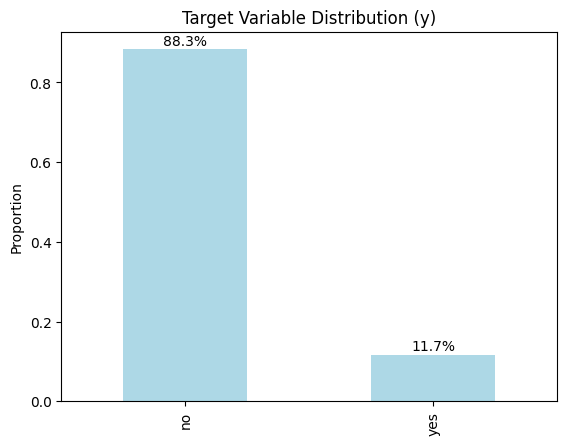

In [8]:
# target variable distribution
ax = bank_full['y'].value_counts(normalize=True).plot(kind='bar', color='lightblue')

plt.title("Target Variable Distribution (y)")
plt.ylabel("Proportion")

# display percentages
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,   
        height + 0.01,                  
        f'{height * 100:.1f}%',        
        ha='center')

plt.show()

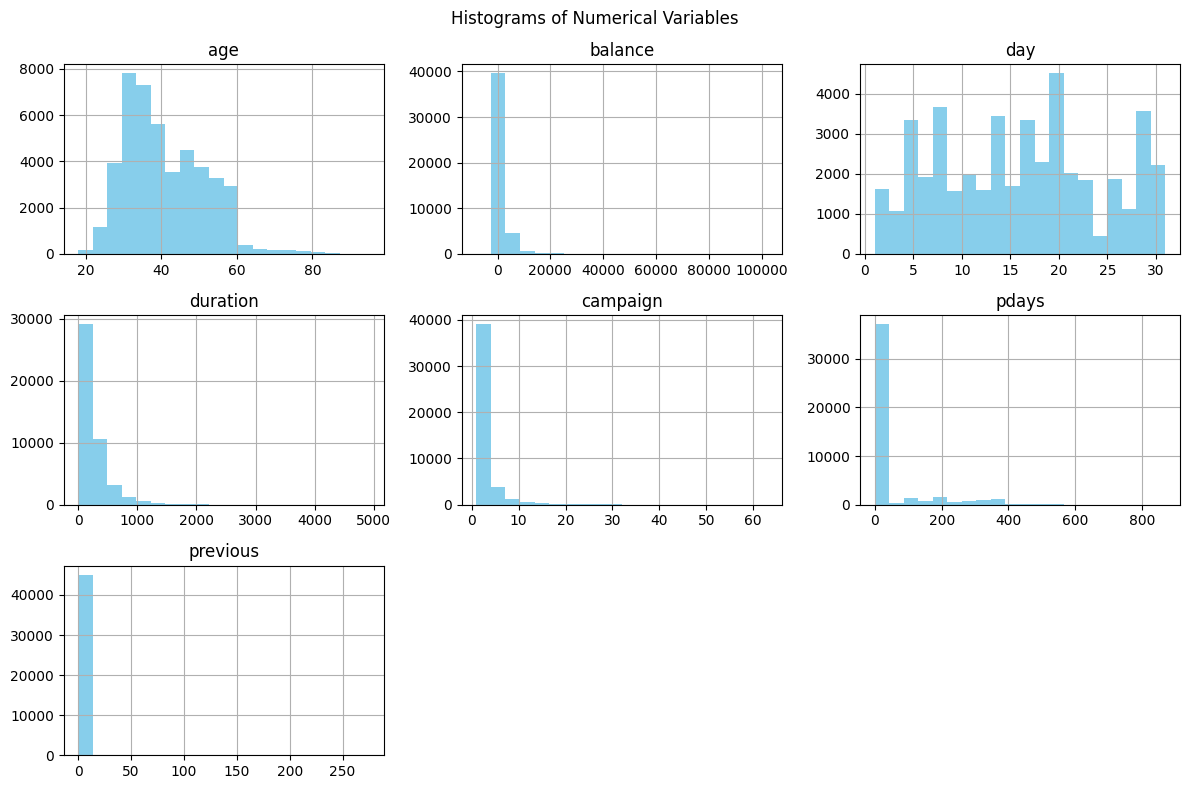

In [9]:
# histogram on numerical variables
num_cols = bank_full.select_dtypes(include=np.number).columns.tolist()
bank_full[num_cols].hist(bins=20, figsize=(12, 8), color='skyblue')
plt.suptitle("Histograms of Numerical Variables")
plt.tight_layout()
plt.show()

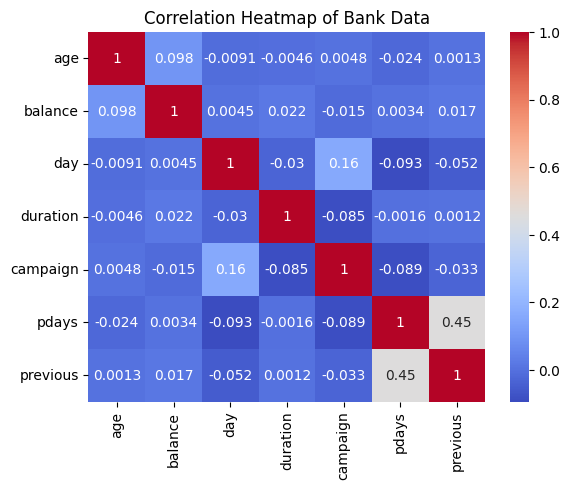

In [14]:
# correlation map
correlation = bank_full.corr(numeric_only=True)
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Bank Data")
plt.show()

## Pre-Processing

In [17]:
# convert the target variable to binary
bank_full['y'] = bank_full['y'].map({'yes': 1, 'no': 0})

# encode the categorical variables
cat_cols = bank_full.select_dtypes(include='object').columns
df_encoded = pd.get_dummies(bank_full, columns=cat_cols, drop_first=True)

print("Encoded dataset shape:", df_encoded.shape)

Encoded dataset shape: (45211, 43)


In [ ]:
# train/test split
